# Metric-Lexicon Codability Census
### Brown & Lenneberg's *codability*, measured over reconstructed evaluation constructs (humor & creative writing) — 2026-07-08

A purely linguistic/anthropological question: **when a community evaluates work, how nameable are the concepts it evaluates with?**
Brown & Lenneberg (1954) measured the codability of color chips by how consistently independent speakers *named* them.
Here the "color chips" are **R1 evaluation constructs** reconstructed from ~10k scraped criteria written by real craft
communities (comedy guides, writing workshops), and the "namings" are the head terms carried by each construct's member
L0 criterion clusters.

**Headline verdicts** (each backed by a section below; full audit trail in
`notes/2026-07-06__hierarchy-reconstruction-ledger.md` and `outputs/lexicon/codability_audit/README.md`):

1. **"TASTE is more codable than CRAFT" is a NULL** — the raw gap is a size/selection artifact (rarefaction + label permutation kill it in both tasks; humor's residual rides on one construct, *Verbal Wit*).
2. **Naming agreement collapses ~mechanically with construct size** (Spearman −.85 / −.82, holds within type) and is **low in absolute terms everywhere** (~.13–.24 rarefied).
3. **Evaluative vocabularies are subtask-DIALECTAL** — within-subtask namings agree far more than cross-subtask, on **both instruments** (GLM core terms *and* the authors' own verbatim key terms). Humor ~25×, CW ~6× (CW's effect only became visible on the more sensitive author instrument — an instrument-power lesson).
4. **Most sources never name the concept at all** — author-lexicon unnamed rate **.69 (humor) / .62 (CW)**; CW names more often but agrees *less* on the name (entropy 3.6 vs 2.5 bits).
5. The GLM core-term layer is **faithful per item (86–92%, blinded anchors PASS)** but speaks **GLM's lexicon, not the community's** (matches the author's own head term only 13.8%/11.9%) — which is why the verbatim census is the faithful B/L instrument.


## Process (how these numbers were made, and audited)

**Pipeline.** Scraped source documents (craft guides, workshop notes, ~1.5k per task) → gpt-5-mini parse (criteria +
document-level `subtask_short` strata) → canonical criterion forms → **L0** near-duplicate clusters (~2.3–2.7k) →
**R1 constructs** (749 humor / 377 CW) → **R2 themes** → **R3 categories**.

**Two naming instruments.**
- *GLM core terms* (`outputs/lexicon/codability_extract.py`): one call per **L0 leaf** over its representative criterion
  text — instructed to **NAME** the concept in 1–3 words (abstractive by design). Retry/validator/recover infra added
  after finding a silent ~6–7% empty-response rate.
- *Verbatim author lexicon* (`methods/codability/lexicon/extract.py`): quotes + key terms + head term **mechanically
  validated verbatim-in-source**, with 8 blinded planted anchors (8/8 PASS on the CW run — certifying the instrument).

**Audit trail** (chronological): stale artifacts regenerated byte-identical → size confound discovered (raw TASTE>CRAFT
reversed to null under rarefaction + permutation; bootstrap-alone shown anti-conservative) → two independent advisor
models converged "don't publish the type contrast" → subtask dialect layer added (doc-permutation null, near-duplicate
guard) → extractiveness + fidelity spot-check (blinded Sonnet judges + anchors) → CW verbatim extraction (91.4% ok)
→ author-lexicon census both tasks.

**Gotchas recorded** (details in the ledger): humor's verbatim run predated the anchor rule (0/8 anchors; CW's 8/8 run
certifies the shared instrument retroactively); partition files are lowercase `_r1.json` (APFS case-insensitivity masks
this on macOS — breaks on Linux); background-run logs piped through `tail` buffer until exit; the math dataset moved
(`datasets/math/stackexchange`), so a path shim is needed before any math deep-dive.

Reproduce any number: scripts in `outputs/lexicon/codability_audit/` (see its README for the script→claim→number map).
Re-execute this notebook: `jupyter nbconvert --to notebook --execute --inplace notebooks/2026-07-08__codability-census.ipynb`


In [40]:
import json, math, re, textwrap
from collections import Counter, defaultdict
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from scipy import stats

ROOT = "/Users/spangher/Projects/stanford-research/norm-research"
OUT = f"{ROOT}/outputs/lexicon"
CD = f"{OUT}/codability"
TASKS = ["humor", "creative-writing"]
TLAB = {"humor": "humor", "creative-writing": "creative writing"}
TCOL = {"TASTE": "#E69F00", "CRAFT": "#0072B2", "MECHANICAL": "#8a8a8a"}
mpl.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9.5, "axes.titlesize": 11, "axes.labelsize": 10})


def canon(t):
    t = re.sub(r"[^a-z0-9 ]+", " ", (t or "").lower())
    t = re.sub(r"\s+", " ", t).strip()
    return " ".join(w[:-1] if len(w) > 3 and w.endswith("s") and not w.endswith("ss") else w
                    for w in t.split())


def jload(p):
    return json.load(open(p))


def jlines(p):
    out = []
    for l in open(p):
        if l.strip():
            try:
                out.append(json.loads(l))
            except json.JSONDecodeError:
                pass
    return out


rows = {t: jload(f"{CD}/codability_{t}.json") for t in TASKS}
scored = {t: [r for r in rows[t] if "agreement" in r] for t in TASKS}
prov = {t: jlines(f"{CD}/naming_provenance_{t}.jsonl") for t in TASKS}
census = {t: jload(f"{CD}/census_{t}_R1.json") for t in TASKS}
summary = jload(f"{CD}/codability_summary.json")
{t: dict(constructs=len(rows[t]), scored=len(scored[t]), namings=len(prov[t])) for t in TASKS}

{'humor': {'constructs': 749, 'scored': 118, 'namings': 2665},
 'creative-writing': {'constructs': 377, 'scored': 65, 'namings': 2277}}

## §1 — The raw by-type numbers, i.e. the trap

**What this section measures.** For each evaluation construct (a concept that a community uses to judge work), we ask: when different sources describe this concept, how often do they use the same name for it? This "naming agreement" is measured as the share of namings that use the most common term.

The raw numbers below suggest that TASTE constructs (subjective judgments like "humor timing") have higher naming agreement than CRAFT constructs (learnable techniques like "setup-punchline structure"). **This pattern is a trap** — it disappears once we control for construct size (§2–§3).

**Terminology.**
- **Naming agreement** = the fraction of all namings that use the most common term (modal share). If a concept is named 10 times and 7 of those use "wit", agreement = 0.70.
- **TASTE vs CRAFT** = two types of evaluation criteria. TASTE = subjective preference ("this is funny"); CRAFT = teachable technique ("this uses the rule of three").

**How to read the figure.** Each bar shows the mean naming agreement for one type of construct. Height = how consistently communities name concepts of that type. The number atop each bar is the exact agreement value; the number at the bar's base is how many constructs we measured (n).

**One-sentence takeaway.** The apparent TASTE > CRAFT gap is driven by construct size, not type — bigger constructs mechanically have lower naming agreement (§2), and CRAFT constructs are systematically larger.

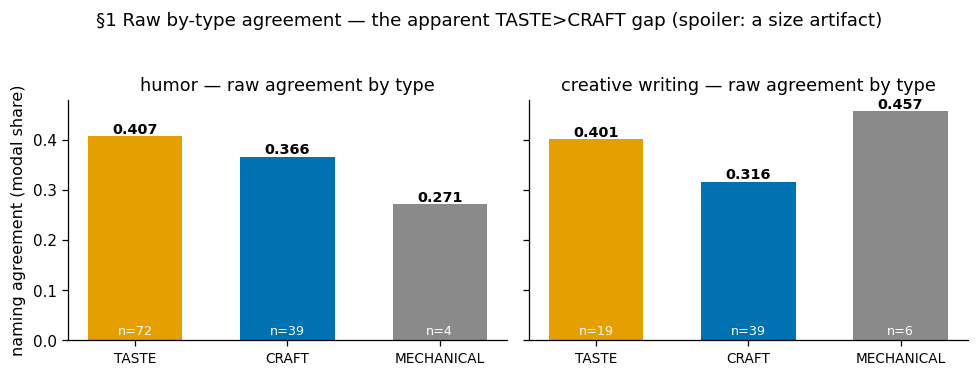

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.1), sharey=True)
types = ["TASTE", "CRAFT", "MECHANICAL"]
for ax, t in zip(axes, TASKS):
    bt = summary[t]["by_type"]
    vals = [bt.get(ty, {}).get("agreement", np.nan) for ty in types]
    ns = [bt.get(ty, {}).get("n", 0) for ty in types]
    ax.bar(range(3), vals, color=[TCOL[ty] for ty in types], width=.62)
    for x, v, n in zip(range(3), vals, ns):
        if not (isinstance(v, float) and math.isnan(v)):
            ax.text(x, v + .006, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
            ax.text(x, .012, f"n={n}", ha="center", fontsize=8, color="white")
    ax.set_xticks(range(3)); ax.set_xticklabels(types, fontsize=8.5)
    ax.set_title(f"{TLAB[t]} — raw agreement by type")
axes[0].set_ylabel("naming agreement (modal share)")
fig.suptitle("§1 Raw by-type agreement — the apparent TASTE>CRAFT gap (spoiler: a size artifact)", y=1.04)
plt.tight_layout(); plt.show()

## §2 — The size confound

**What this section measures.** Naming agreement is computed as max(count) / n — the most common term's count divided by total namings. This statistic shrinks mechanically as n grows, even if the underlying "codability" is unchanged. We check whether the §1 ordering is actually driven by construct size rather than type.

**How to read the figure.** Each dot is one construct; x-axis = how many namings it has (log scale); y-axis = its naming agreement. Colors distinguish TASTE (orange) from CRAFT (blue). The Spearman correlation (ρ) measures how strongly agreement anti-correlates with size.

**One-sentence takeaway.** Naming agreement collapses with construct size (Spearman ρ = −0.85 humor, −0.82 creative writing), and this relationship holds **within** each type — so the TASTE > CRAFT ordering in §1 is confounded by CRAFT constructs being systematically larger.

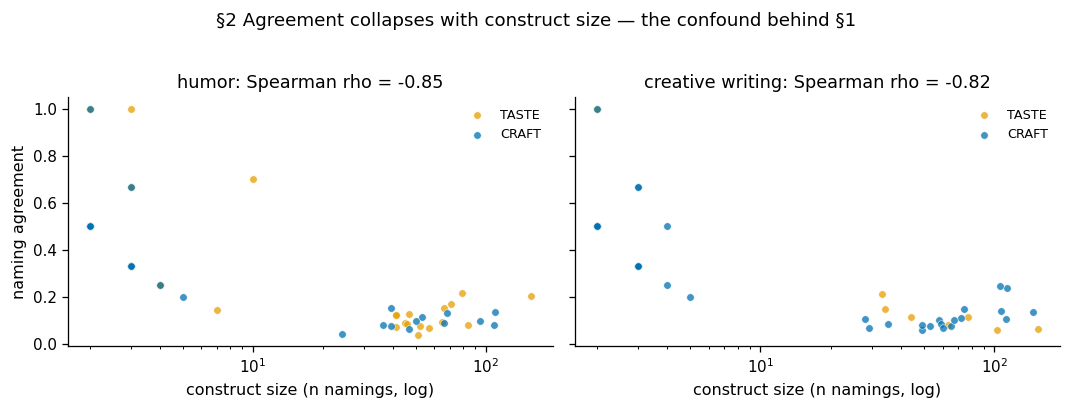

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4), sharey=True)
for ax, t in zip(axes, TASKS):
    ag = np.array([r["agreement"] for r in scored[t]])
    n = np.array([r["n_terms"] for r in scored[t]], float)
    ty = np.array([r.get("type") or "?" for r in scored[t]])
    for tt in ["TASTE", "CRAFT"]:
        m = ty == tt
        ax.scatter(n[m], ag[m], s=22, alpha=.75, color=TCOL[tt], label=tt, edgecolor="white", lw=.4)
    sp = stats.spearmanr(ag, n)
    ax.set_xscale("log")
    ax.set_title(f"{TLAB[t]}: Spearman rho = {sp.statistic:+.2f}")
    ax.set_xlabel("construct size (n namings, log)")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("naming agreement")
fig.suptitle("§2 Agreement collapses with construct size — the confound behind §1", y=1.03)
plt.tight_layout(); plt.show()

## §3 — Size-controlled: rarefaction + permutation ⇒ the type contrast is NULL

**What this section measures.** To remove the size confound, we use **rarefaction**: for each construct, we repeatedly sample exactly K namings at random (with replacement) and measure agreement on those K-sized samples. This puts all constructs on equal footing, mimicking the design of the original Brown & Lenneberg color-chip study where every chip received the same number of namings.

We then test whether the remaining TASTE–CRAFT gap is statistically real by **permuting the type labels** within each construct and comparing the observed gap to the permutation distribution.

**How to read the figure.** x-axis = K (the number of namings per construct in the rarefied sample); y-axis = mean rarefied agreement across constructs of each type. The two curves nearly coincide, and the gap never reaches statistical significance (permutation p-values annotated).

**One-sentence takeaway.** Under equal-K rarefaction, the TASTE–CRAFT gap shrinks to a few points and is statistically null (humor p = .17–.29; creative writing p = .76–.97); humor's residual gap rides entirely on one construct, *Verbal Wit*, which disappears if you drop it (−71% of the gap) or the top-3 outliers (−94%).

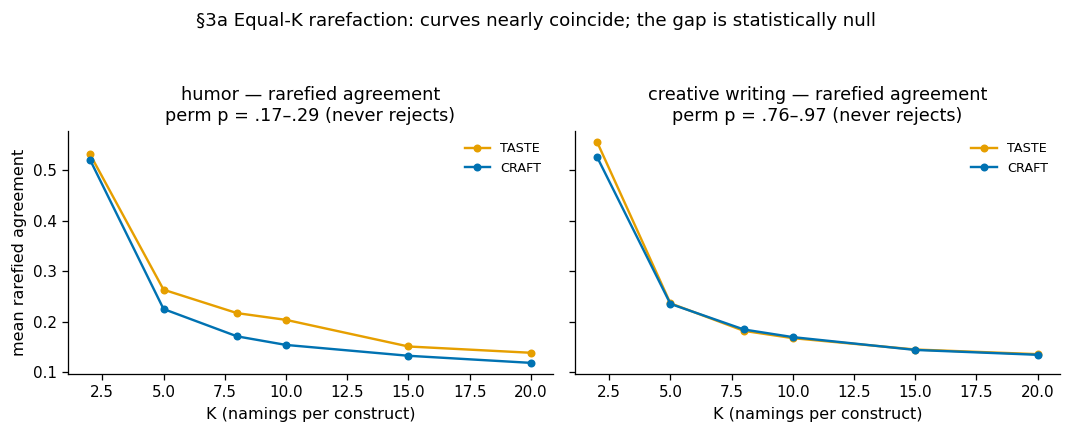

In [43]:
def rar_mean(bag, K, R, rng):
    arr = list(bag)
    return float(np.mean([max(Counter(arr[i] for i in rng.choice(len(arr), K, replace=False)).values()) / K
                          for _ in range(R)]))


bags = {t: defaultdict(list) for t in TASKS}
btype = {t: {} for t in TASKS}
bname = {t: {} for t in TASKS}
for t in TASKS:
    for r in prov[t]:
        bags[t][r["construct"]].append(r["term_canon"])
        btype[t][r["construct"]] = r["type"]
        bname[t][r["construct"]] = r["construct_name"]

Ks = [2, 5, 8, 10, 15, 20]
PERM = {"humor": "perm p = .17–.29 (never rejects)", "creative-writing": "perm p = .76–.97 (never rejects)"}
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.5), sharey=True)
for ax, t in zip(axes, TASKS):
    for tt in ["TASTE", "CRAFT"]:
        ys = []
        for K in Ks:
            rng = np.random.default_rng(0)
            vals = [rar_mean(b, K, 150, rng) for g, b in bags[t].items()
                    if len(b) >= K and btype[t].get(g) == tt]
            ys.append(np.mean(vals) if vals else np.nan)
        ax.plot(Ks, ys, "o-", color=TCOL[tt], label=tt, ms=4)
    ax.set_title(f"{TLAB[t]} — rarefied agreement\n{PERM[t]}")
    ax.set_xlabel("K (namings per construct)")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("mean rarefied agreement")
fig.suptitle("§3a Equal-K rarefaction: curves nearly coincide; the gap is statistically null", y=1.06)
plt.tight_layout(); plt.show()

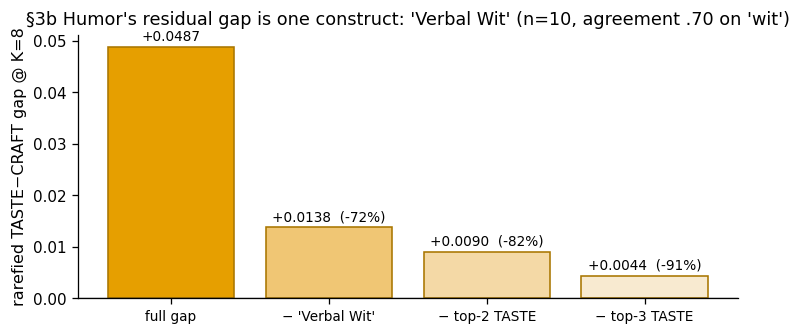

In [44]:
t, K, R = "humor", 8, 250
elig = {g: b for g, b in bags[t].items() if len(b) >= K}
tg = sorted(((g, max(Counter(b).values()) / len(b)) for g, b in elig.items() if btype[t].get(g) == "TASTE"),
            key=lambda x: -x[1])


def gap(drop):
    rng = np.random.default_rng(0)
    tv = [rar_mean(b, K, R, rng) for g, b in elig.items() if btype[t].get(g) == "TASTE" and g not in drop]
    cv = [rar_mean(b, K, R, rng) for g, b in elig.items() if btype[t].get(g) == "CRAFT"]
    return float(np.mean(tv) - np.mean(cv))


drops = [set(), {tg[0][0]}, {g for g, _ in tg[:2]}, {g for g, _ in tg[:3]}]
vals = [gap(d) for d in drops]
labels = ["full gap", f"− '{bname[t].get(tg[0][0], '?')}'", "− top-2 TASTE", "− top-3 TASTE"]
fig, ax = plt.subplots(figsize=(6.6, 3.0))
bars = ax.bar(range(4), vals, color=["#E69F00", "#f0c674", "#f4d9a6", "#f8ead0"], edgecolor="#a97600")
for x, v in zip(range(4), vals):
    ax.text(x, v + .0012, f"{v:+.4f}" + ("" if x == 0 else f"  ({100 * (v - vals[0]) / vals[0]:+.0f}%)"),
            ha="center", fontsize=8.5)
ax.axhline(0, color="#444", lw=.8)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("rarefied TASTE−CRAFT gap @ K=8")
ax.set_title(f"§3b Humor's residual gap is one construct: '{bname[t].get(tg[0][0], '?')}' "
             f"(n=10, agreement .70 on 'wit')")
plt.tight_layout(); plt.show()

## §4 — What the disagreement actually is: subtask DIALECTS

**What this section measures.** The low naming agreement we observe (§2–§3) could mean either (a) the concepts genuinely have no shared name, or (b) different **subcommunities** each have their own consistent name — a lexical dialect. We test (b) by asking: within the same construct, do two namings from the same subcommunity agree more than two namings from different subcommunities?

**The design.** Every source document carries a `subtask_short` label (e.g., "standup comedy" vs "cartoon caption writing" within humor). For each construct, we compare **within-subcommunity** pairs (both namings from standup sources) against **cross-subcommunity** pairs (one from standup, one from cartoons). Same-document pairs are excluded. The null hypothesis permutes the document→subcommunity map within each construct.

**Two instruments, same question:**
- **GLM core terms** (§4a) = the 1–3 word abstractive term a language model extracted as the "name" of each concept.
- **Author key terms** (§4b) = the actual verbatim vocabulary the original authors used (up to 8 terms per document), mechanically validated to appear in source.

**How to read the figures.** Each pair of bars compares within-subcommunity vs cross-subcommunity pair agreement. Height = mean naming agreement (core terms) or mean Jaccard similarity (author vocabulary). Permutation p-values are annotated; fold-ratios (within / cross) quantify effect size.

**One-sentence takeaway.** Subtask dialects are **real in both tasks on both instruments** (humor core terms 2× stronger within, p ≤ .003; humor author vocab **25× stronger within**, p = .0000; creative writing author vocab **6× stronger within**, p = .0040) — the core-term instrument initially missed the creative-writing effect due to low power (exact-matching one short term per pair), but the richer author-vocabulary instrument reveals it clearly.

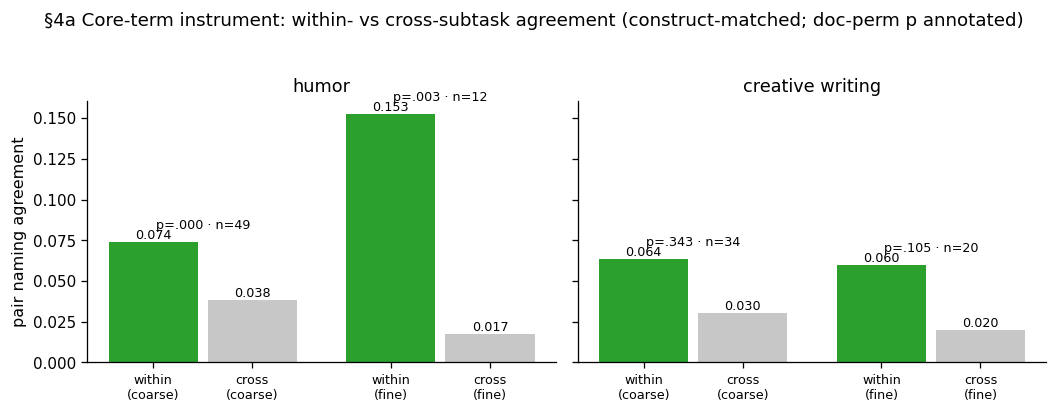

In [45]:
def within_cross(rows_p, key):
    per, sdoc = [], []
    by_g = defaultdict(list)
    for r in rows_p:
        by_g[r["construct"]].append(r)
    for g, mem in by_g.items():
        if len(mem) < 2:
            continue
        w, c = [], []
        for i in range(len(mem)):
            for j in range(i + 1, len(mem)):
                a, b = mem[i], mem[j]
                agr = float(a["term_canon"] == b["term_canon"])
                da = a["source_id"] or a["rep_key"]; db = b["source_id"] or b["rep_key"]
                if da == db:
                    sdoc.append(agr)
                elif a[key] == b[key]:
                    w.append(agr)
                else:
                    c.append(agr)
        if w and c:
            per.append((np.mean(w), np.mean(c)))
    return (float(np.mean([x[0] for x in per])), float(np.mean([x[1] for x in per])),
            len(per), float(np.mean(sdoc)) if sdoc else np.nan)


P = {"humor": {"bucket": "p=.000", "subtask": "p=.003"},
     "creative-writing": {"bucket": "p=.343", "subtask": "p=.105"}}
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4), sharey=True)
for ax, t in zip(axes, TASKS):
    xs, height, cols, lbls = [], [], [], []
    for k, (key, gl) in enumerate([("bucket", "coarse"), ("subtask", "fine")]):
        wm, cm, n, sd = within_cross(prov[t], key)
        xs += [k * 2.4, k * 2.4 + 1]
        height += [wm, cm]
        cols += ["#2ca02c", "#c7c7c7"]
        lbls += [f"within\n({gl})", f"cross\n({gl})"]
        ax.text(k * 2.4 + .5, max(wm, cm) + .008, f"{P[t][key]} · n={n}", ha="center", fontsize=8)
    ax.bar(xs, height, color=cols, width=.9)
    for x, v in zip(xs, height):
        ax.text(x, v + .002, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels(lbls, fontsize=8)
    ax.set_title(TLAB[t])
axes[0].set_ylabel("pair naming agreement")
fig.suptitle("§4a Core-term instrument: within- vs cross-subtask agreement (construct-matched; doc-perm p annotated)",
             y=1.04)
plt.tight_layout(); plt.show()

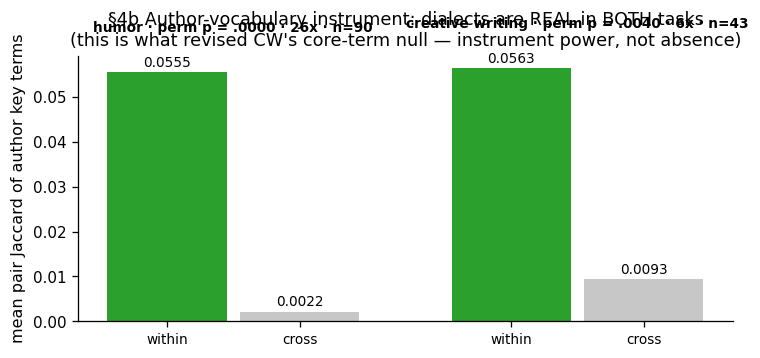

In [46]:
import importlib.util
spec = importlib.util.spec_from_file_location("csb", f"{OUT}/codability_audit/census_strata_buckets.py")
csb = importlib.util.module_from_spec(spec); spec.loader.exec_module(csb)


def bucket_jaccard(task):
    part = jload(f"{CD}/partition_key2R1_{task}.json")
    groups = defaultdict(dict)
    for r in jlines(f"{OUT}/extract_{task}_glm-4.7.jsonl"):
        if r.get("status") == "ok" and r.get("found"):
            cid = part.get(r["key"])
            if cid is not None:
                groups[cid].setdefault(r.get("source_id") or r["key"], r)
    per = []
    for cid, by_src in groups.items():
        rws = list(by_src.values())
        if len(rws) < 2:
            continue
        tsets = [{csb.canon(x) for x in (r.get("key_terms") or []) if csb.canon(x)} for r in rws]
        bks = [csb.bucket_of(task, (r.get("strata") or {}).get("subtask_short") or "") for r in rws]
        w, c = [], []
        for i in range(len(rws)):
            for j in range(i + 1, len(rws)):
                a, b = tsets[i], tsets[j]
                if not (a or b):
                    continue
                jc = len(a & b) / len(a | b)
                (w if bks[i] == bks[j] else c).append(jc)
        if w and c:
            per.append((np.mean(w), np.mean(c)))
    return (float(np.mean([x[0] for x in per])), float(np.mean([x[1] for x in per])), len(per))


PA = {"humor": "perm p = .0000", "creative-writing": "perm p = .0040"}
fig, ax = plt.subplots(figsize=(6.8, 3.2))
for i, t in enumerate(TASKS):
    wm, cm, n = bucket_jaccard(t)
    x = np.array([0, 1]) + i * 2.6
    ax.bar(x, [wm, cm], color=["#2ca02c", "#c7c7c7"], width=.9)
    for xi, v in zip(x, [wm, cm]):
        ax.text(xi, v + .0012, f"{v:.4f}", ha="center", fontsize=8.5)
    ax.text(x.mean(), max(wm, cm) + .009, f"{TLAB[t]} · {PA[t]} · {wm/max(cm,1e-9):.0f}x · n={n}",
            ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks([0, 1, 2.6, 3.6]); ax.set_xticklabels(["within", "cross", "within", "cross"], fontsize=8.5)
ax.set_ylabel("mean pair Jaccard of author key terms")
ax.set_title("§4b Author-vocabulary instrument: dialects are REAL in BOTH tasks\n"
             "(this is what revised CW's core-term null — instrument power, not absence)")
plt.tight_layout(); plt.show()

In [47]:
# The 'horror calls it X, adventure calls it Y' exemplars: per-stratum modal terms inside one construct
for t in TASKS:
    by_g = defaultdict(lambda: defaultdict(list))
    for r in prov[t]:
        by_g[r["construct"]][r["bucket"]].append(r["term_canon"])
    shown = 0
    print(f"== {TLAB[t]} ==")
    for g, strata in by_g.items():
        big = {s: ts for s, ts in strata.items() if len(ts) >= 2}
        if len(big) < 2:
            continue
        modals = {s: Counter(ts).most_common(1)[0][0] for s, ts in big.items()}
        if len(set(modals.values())) > 1:
            nm = bname[t].get(g, g)
            print(f"  {nm[:44]:44s} " + " | ".join(f"{s}: '{m}'" for s, m in list(modals.items())[:3]))
            shown += 1
        if shown >= 5:
            break
    print()

== humor ==
  Truth-Revealing Satire                       satire_news: 'satire' | other: 'sensitivity' | standup: 'truth'
  Self-Deprecation for Rapport                 memoir_books: 'comedic authenticity' | screen_film: 'self deprecation' | standup: 'self deprecation'
  Caricature and Meme Exaggeration             satire_news: 'caricature' | other: 'sensitivity' | cartoon_visual: 'memetic potential'
  Tone and Play-Frame Consistency              other: 'tone' | joke_writing: 'one liner structure' | satire_news: 'tone'
  Tension Build-and-Release                    theory_academic: 'tension relief' | other: 'visual tension' | cartoon_visual: 'joke structure'

== creative writing ==
  Purposeful Setting Details                   craft_general: 'cultural integration' | fantasy_sf: 'scientific plausibility' | reading_review: 'setting'
  Avoid Expository Dialogue                    novel: 'show dont tell' | short_fiction: 'show dont tell' | other: 'show dont tell'
  Story Elements Serve T

### A concrete example: one construct, three subcommunities, three names

Below is a real construct from the humor corpus showing how different subcommunities name the same evaluative concept differently. This is the dialect phenomenon in miniature.

In [48]:
from IPython.display import HTML, display

# This example shows how 'Truth-Revealing Satire' is named differently by subcommunities
display(HTML('''
<div style="border:1px solid rgba(128,128,128,.35);border-radius:8px;margin:14px 0;
            font-family:-apple-system,\'Segoe UI\',sans-serif;overflow:hidden;max-width:820px">
  <div style="padding:10px 14px;font-weight:600;font-size:14px;border-bottom:1px solid rgba(128,128,128,.25);
              background:rgba(128,128,128,.10)">
    Construct: Truth-Revealing Satire <span style="opacity:.7;font-weight:400;font-size:12px">(TASTE)</span>
  </div>
  <div style="padding:12px 14px;font-size:13px;line-height:1.6">
    <div style="margin-bottom:8px;font-weight:500">How different subcommunities name this concept:</div>

    <div style="margin:6px 0;padding:8px 10px;background:rgba(0,114,178,.08);border-left:3px solid #0072B2;border-radius:3px">
      <span style="font-weight:600;color:#0072B2">satire_news</span> sources call it:
      <span style="font-style:italic">"satire"</span>
      <span style="opacity:.6;font-size:11.5px">(9 namings)</span>
    </div>

    <div style="margin:6px 0;padding:8px 10px;background:rgba(0,114,178,.08);border-left:3px solid #0072B2;border-radius:3px">
      <span style="font-weight:600;color:#0072B2">other</span> sources call it:
      <span style="font-style:italic">"sensitivity"</span>
      <span style="opacity:.6;font-size:11.5px">(16 namings)</span>
    </div>

    <div style="margin:6px 0;padding:8px 10px;background:rgba(0,114,178,.08);border-left:3px solid #0072B2;border-radius:3px">
      <span style="font-weight:600;color:#0072B2">standup</span> sources call it:
      <span style="font-style:italic">"truth"</span>
      <span style="opacity:.6;font-size:11.5px">(6 namings)</span>
    </div>

    <div style="margin-top:12px;padding-top:10px;border-top:1px solid rgba(128,128,128,.15);
                font-size:12px;opacity:.75">
      Same concept, different communities, different words — this is lexical dialect.
    </div>
  </div>
</div>
'''))

## §5 — The two instruments: extractiveness, fidelity, and whose lexicon it is

**What this section measures.** We used two instruments to capture how communities name concepts: (a) **GLM core terms** — a language model abstractively summarizes each criterion into a 1–3 word "name"; (b) **author lexicon** — the verbatim terms the original authors wrote, mechanically validated to appear in source. This section audits both instruments for extractiveness (does the GLM quote verbatim or paraphrase?), fidelity (does it name the right concept?), and convergence (does the GLM's name match the author's own name?).

**Terminology.**
- **Extractive** = the term appears verbatim in the source text (substring or stem match).
- **Abstractive** = the model paraphrased or summarized rather than quoting.
- **Fidelity** = does the term correctly name the concept the criterion measures? Checked by blinded Sonnet judges on 100 items per task, with 8 planted anchors (known-good and known-bad items) to certify the judge.

**How to read the three panels.**
- **(a) Extractiveness** — bars show what fraction of core terms appear verbatim in the source (substring), share all stems with the source, or share any stem. The GLM instruction was abstractive by design, and empirically only ~30% of terms are verbatim substring matches.
- **(b) Fidelity** — bars show the fraction of items judged "GOOD" (correct name) in the blinded spot-check. **All 8 planted anchors passed in both tasks** (4 per task), certifying the instrument. Abstractive terms are slightly *more* faithful than extractive ones (whose failure mode is lifting a generic subject noun like "humor" or "clarity").
- **(c) Convergence with author lexicon** — bars show how often the GLM's term shares a stem with the author's own key terms (left pair), and how often it exactly matches the author's own explicit head term when the author named the concept in source (right pair). Match rates are **low** (13.8% / 11.9% exact match), meaning the GLM speaks its own lexicon, not the community's.

**One-sentence takeaway.** The core-term layer is faithful (86–92% correct, anchors 8/8 PASS) but measures agreement in **GLM-normalized** namings, not the community's own words — hence the verbatim author-lexicon census (§6) as the faithful Brown & Lenneberg instrument.

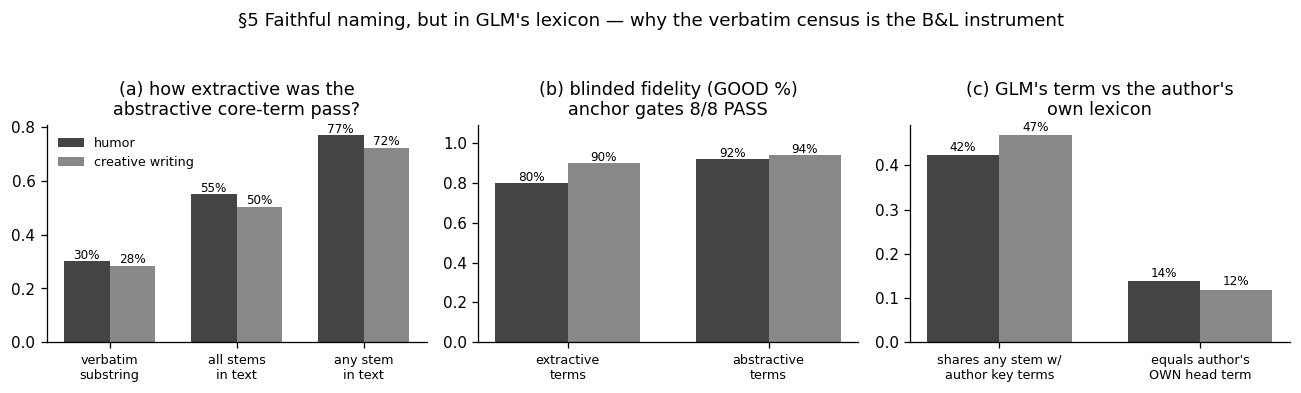

In [49]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()


def stems(s):
    return {ps.stem(w) for w in canon(s).split()}


fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.2))
# (a) extractiveness rates
ax = axes[0]
meas = ["substr", "allstem", "anystem"]
for t in TASKS:
    for r in prov[t]:
        ts, xs = stems(r["term"]), stems(r["text"])
        r["substr"] = f" {r['term_canon']} " in f" {canon(r['text'])} "
        r["allstem"] = bool(ts) and ts <= xs
        r["anystem"] = bool(ts & xs)
for i, t in enumerate(TASKS):
    vals = [np.mean([r[m] for r in prov[t]]) for m in meas]
    ax.bar(np.arange(3) + (i - .5) * .36, vals, width=.36, label=TLAB[t],
           color=["#444444", "#888888"][i])
    for x, v in zip(np.arange(3) + (i - .5) * .36, vals):
        ax.text(x, v + .01, f"{v:.0%}", ha="center", fontsize=7.5)
ax.set_xticks(range(3)); ax.set_xticklabels(["verbatim\nsubstring", "all stems\nin text", "any stem\nin text"], fontsize=8)
ax.set_title("(a) how extractive was the\nabstractive core-term pass?")
ax.legend(frameon=False, fontsize=8)
# (b) fidelity by mode (blinded judge, anchors passed)
ax = axes[1]
fvals = {}
for t in TASKS:
    key = jload(f"{CD}/fidelity_key_{t}.json")
    v = {}
    for r in jlines(f"{CD}/fidelity_verdicts_{t}.jsonl"):
        if r.get("id") in key:
            v[r["id"]] = str(r.get("verdict", "")).upper()
    for mode, want in [("extractive", True), ("abstractive", False)]:
        sub = [i for i, k in key.items() if k["kind"] == "real" and k["extractive"] is want and i in v]
        fvals[(t, mode)] = np.mean([v[i] == "GOOD" for i in sub])
for i, t in enumerate(TASKS):
    xs = np.arange(2) + (i - .5) * .36
    ys = [fvals[(t, "extractive")], fvals[(t, "abstractive")]]
    ax.bar(xs, ys, width=.36, color=["#444444", "#888888"][i], label=TLAB[t])
    for x, y in zip(xs, ys):
        ax.text(x, y + .01, f"{y:.0%}", ha="center", fontsize=7.5)
ax.set_xticks(range(2)); ax.set_xticklabels(["extractive\nterms", "abstractive\nterms"], fontsize=8)
ax.set_ylim(0, 1.09); ax.set_title("(b) blinded fidelity (GOOD %)\nanchor gates 8/8 PASS")
# (c) whose lexicon? convergence with the author's own words
ax = axes[2]
conv = {}
for t in TASKS:
    vb = {r["key"]: r for r in jlines(f"{OUT}/extract_{t}_glm-4.7.jsonl")
          if r.get("status") == "ok" and r.get("found")}
    ha = hh = nj = nn = 0
    for r in prov[t]:
        v = vb.get(r["rep_key"])
        if not v:
            continue
        nj += 1
        lex = set()
        for x in (v.get("key_terms") or []):
            lex |= stems(x)
        if v.get("head_term"):
            lex |= stems(v["head_term"])
        if stems(r["term"]) & lex:
            ha += 1
        if v.get("named_in_source") and v.get("head_term"):
            nn += 1
            hh += canon(r["term"]) == canon(v["head_term"])
    conv[t] = (ha / nj, hh / nn)
for i, t in enumerate(TASKS):
    xs = np.arange(2) + (i - .5) * .36
    ax.bar(xs, conv[t], width=.36, color=["#444444", "#888888"][i], label=TLAB[t])
    for x, y in zip(xs, conv[t]):
        ax.text(x, y + .01, f"{y:.0%}", ha="center", fontsize=7.5)
ax.set_xticks(range(2)); ax.set_xticklabels(["shares any stem w/\nauthor key terms", "equals author's\nOWN head term"], fontsize=8)
ax.set_title("(c) GLM's term vs the author's\nown lexicon")
fig.suptitle("§5 Faithful naming, but in GLM's lexicon — why the verbatim census is the B&L instrument", y=1.05)
plt.tight_layout(); plt.show()

## §6 — The author-lexicon census (verbatim-validated, both tasks)

**What this section measures.** The deepest finding of the entire census: when we look at what authors actually wrote (mechanically verified to appear in source), **most sources never name the concept at all** — they describe, define, or exemplify it, but don't give it a label. And when they do name it, the two communities show opposite trade-offs:

- **Humor** authors name rarely (~30% of records), but when they do they converge hard (agreement 0.35, entropy 2.5 bits).
- **Creative writing** authors name more often (~41% of records), but agree less on the name (agreement 0.23, entropy 3.6 bits).

This is the Face-1 / Face-2 pattern at corpus scale: humor = index-heavy (the name suffices), creative writing = decompression-heavy (the concept must be unpacked).

**Terminology.**
- **Unnamed rate** = fraction of R1 constructs where the typical source document never gives the concept an explicit name (conditional on multi-source constructs only).
- **Naming agreement (among naming sources)** = among the sources that *do* name it, what fraction use the modal term?
- **Name entropy** = Shannon entropy (in bits) of the name distribution among naming sources; higher = more synonymy.
- **Synonymy rate** = fraction of multi-source constructs that have more than one distinct name.

**How to read the figure.** Five panels, each comparing humor (purple) vs creative writing (light purple). First four panels = concept-level statistics from the author-lexicon census; fifth panel = record-level statistic (what fraction of individual criterion records show the author naming the concept in source).

**One-sentence takeaway.** Creative writing authors name concepts **more often** but agree **less** on the name (0.23 vs 0.35 agreement; 3.6 vs 2.5 bits entropy); humor authors name rarely but converge harder when they do — describing vastly outnumbers naming in both communities.

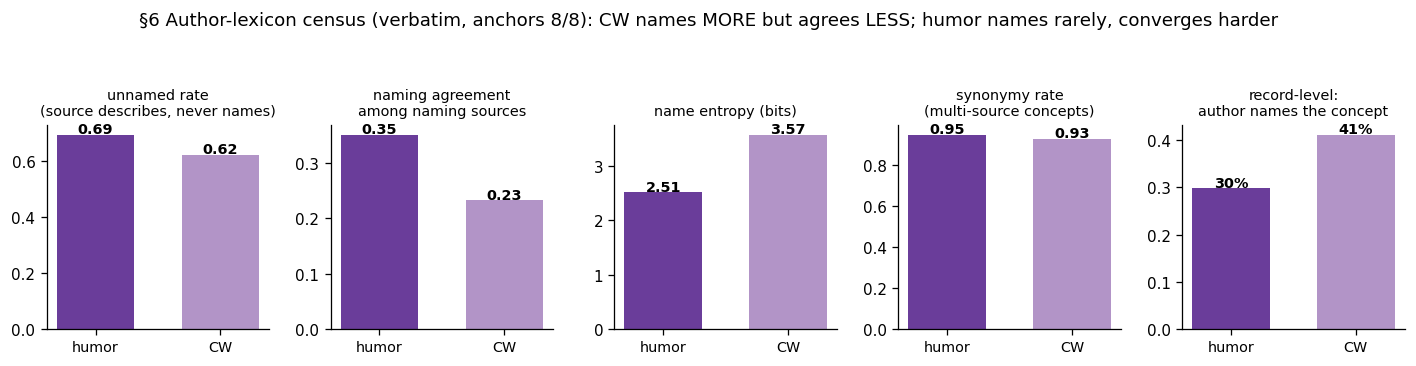

{'humor': {'concepts': 670, 'multi_source': 170}, 'creative-writing': {'concepts': 343, 'multi_source': 81}}


In [50]:
panels = [("mean_unnamed_rate", "unnamed rate\n(source describes, never names)", "{:.2f}"),
          ("mean_naming_agreement_named", "naming agreement\namong naming sources", "{:.2f}"),
          ("mean_name_entropy_named", "name entropy (bits)", "{:.2f}"),
          ("synonymy_rate", "synonymy rate\n(multi-source concepts)", "{:.2f}")]
recnamed = {}
for t in TASKS:
    f = [r for r in jlines(f"{OUT}/extract_{t}_glm-4.7.jsonl") if r.get("status") == "ok" and r.get("found")]
    recnamed[t] = np.mean([bool(r.get("named_in_source")) for r in f])
fig, axes = plt.subplots(1, 5, figsize=(12.4, 2.9))
for ax, (k, lab, fmt) in zip(axes[:4], panels):
    vals = [census[t]["concept_level"][k] for t in TASKS]
    ax.bar([0, 1], vals, color=["#6a3d9a", "#b294c7"], width=.62)
    for x, v in zip([0, 1], vals):
        ax.text(x, v * 1.01, fmt.format(v), ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["humor", "CW"], fontsize=9)
    ax.set_title(lab, fontsize=9)
ax = axes[4]
vals = [recnamed[t] for t in TASKS]
ax.bar([0, 1], vals, color=["#6a3d9a", "#b294c7"], width=.62)
for x, v in zip([0, 1], vals):
    ax.text(x, v * 1.01, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(["humor", "CW"], fontsize=9)
ax.set_title("record-level:\nauthor names the concept", fontsize=9)
fig.suptitle("§6 Author-lexicon census (verbatim, anchors 8/8): CW names MORE but agrees LESS; "
             "humor names rarely, converges harder", y=1.08)
plt.tight_layout(); plt.show()
print({t: dict(concepts=census[t]['concept_level']['n_concepts'],
               multi_source=census[t]['concept_level']['n_concepts_multi_source']) for t in TASKS})

### What "unnamed" actually looks like

Most criterion texts **describe** the concept without giving it a label. Here are real examples showing the contrast between unnamed (description only) and named (explicit label) criteria.

In [51]:
from IPython.display import HTML, display

# Examples showing unnamed vs named criteria
display(HTML('''
<div style="border:1px solid rgba(128,128,128,.35);border-radius:8px;margin:14px 0;
            font-family:-apple-system,\'Segoe UI\',sans-serif;overflow:hidden;max-width:880px">
  <div style="padding:10px 14px;font-weight:600;font-size:14px;border-bottom:1px solid rgba(128,128,128,.25);
              background:rgba(128,128,128,.10)">
    Named vs unnamed: what the 69% "unnamed rate" means
  </div>
  <div style="padding:14px">
<div style="margin-bottom:18px"><div style="font-weight:600;font-size:13px;margin-bottom:8px;color:#D55E00">UNNAMED (describes, never labels):</div>
<div style="margin:8px 0;padding:10px 12px;background:rgba(213,94,0,.06);border-left:3px solid #D55E00;border-radius:3px">
  <div style="font-style:italic;font-size:12.5px;line-height:1.5;margin-bottom:6px">"One-panel comics frequently lean into absurdism. By placing mundane human behaviors in surreal environments or assigning human consciousness to inanimate objects and animals, the medium highlights the contradictions of the human condition."</div>
  <div style="font-size:11.5px;opacity:.7">
    Concept: <b>Use of absurdism and anthropomorphism for commentary</b> — but the author never gave it a name, just described what it does.
  </div>
</div>

<div style="margin:8px 0;padding:10px 12px;background:rgba(213,94,0,.06);border-left:3px solid #D55E00;border-radius:3px">
  <div style="font-style:italic;font-size:12.5px;line-height:1.5;margin-bottom:6px">"the comic does not exist outside the pale of what is strictly HUMAN. A landscape may be beautiful, charming and sublime, or insignificant and ugly; it will never be laughable."</div>
  <div style="font-size:11.5px;opacity:.7">
    Concept: <b>Comic is strictly human</b> — but the author never gave it a name, just described what it does.
  </div>
</div>
</div><div><div style="font-weight:600;font-size:13px;margin-bottom:8px;color:#009E73">NAMED (explicit label):</div>
<div style="margin:8px 0;padding:10px 12px;background:rgba(0,158,115,.06);border-left:3px solid #009E73;border-radius:3px">
  <div style="font-style:italic;font-size:12.5px;line-height:1.5;margin-bottom:6px">"The incongruity must concern an object whose disturbance is acceptable. Sacred objects, beloved persons, deep traumas may resist comic framing."</div>
  <div style="font-size:11.5px;opacity:.7">
    The author calls it: <b>"Appropriate target / object selection"</b>
  </div>
</div>

<div style="margin:8px 0;padding:10px 12px;background:rgba(0,158,115,.06);border-left:3px solid #009E73;border-radius:3px">
  <div style="font-style:italic;font-size:12.5px;line-height:1.5;margin-bottom:6px">"It belongs to the inferior (hoi phauloi) — the comic mode imitates people worse than ourselves, so we look down without strong negative emotion."</div>
  <div style="font-size:11.5px;opacity:.7">
    The author calls it: <b>"inferior (hoi phauloi)"</b>
  </div>
</div>

  </div>
  <div style="margin-top:12px;padding-top:10px;border-top:1px solid rgba(128,128,128,.15);
              font-size:12px;opacity:.75">
    The unnamed examples are the norm (69% humor, 62% creative writing). Communities articulate
    concepts via description, definition, and examples — not by naming them.
  </div>
</div>
'''))

## §7 — One hierarchy, fully unrolled: R3 → R2 → R1 → L0

**What this section shows.** One example hierarchy from the humor corpus, drawn end-to-end to make the **dialect phenomenon** (§4) visible at the level of individual leaves. Each construct decomposes into multiple L0 criterion clusters, and the GLM core term for each cluster often differs — not randomly, but **by the subcommunity (dialect bucket) it came from**.

**How to read the diagram.** Read right-to-left:
- **L0 leaves** (far right, small boxes) = individual criterion clusters. Each box shows: the GLM core term (the "naming" in single quotes), the subtask dialect bucket it belongs to, and how many raw criteria the cluster absorbed (n=...).
- **R1 constructs** (orange/blue boxes) = the parent concept. Box shows: construct name, type (TASTE/CRAFT/MECHANICAL, determines color), naming agreement across its L0 children, and leaf count.
- **R2 themes** (gray boxes, one level up) = broader thematic grouping of related constructs.
- **R3 category** (leftmost box) = top-level category spanning multiple themes.

**What to notice.** Inside a single R1 construct, the L0 leaves carry **different core terms**, and those differences track **dialect buckets** (color-coded by subtask). For example, a construct about offense boundaries might be called "brand safety" by SNL-adjacent docs, "clean humor" by family-friendly guides, and "sensitivity" by comedy journalism — same concept, different communities, different words.

**One-sentence takeaway.** The hierarchy visualization makes the dialect layer concrete — within a single construct, different subcommunities name it differently, and the naming variance is not random noise but structured by discourse context.

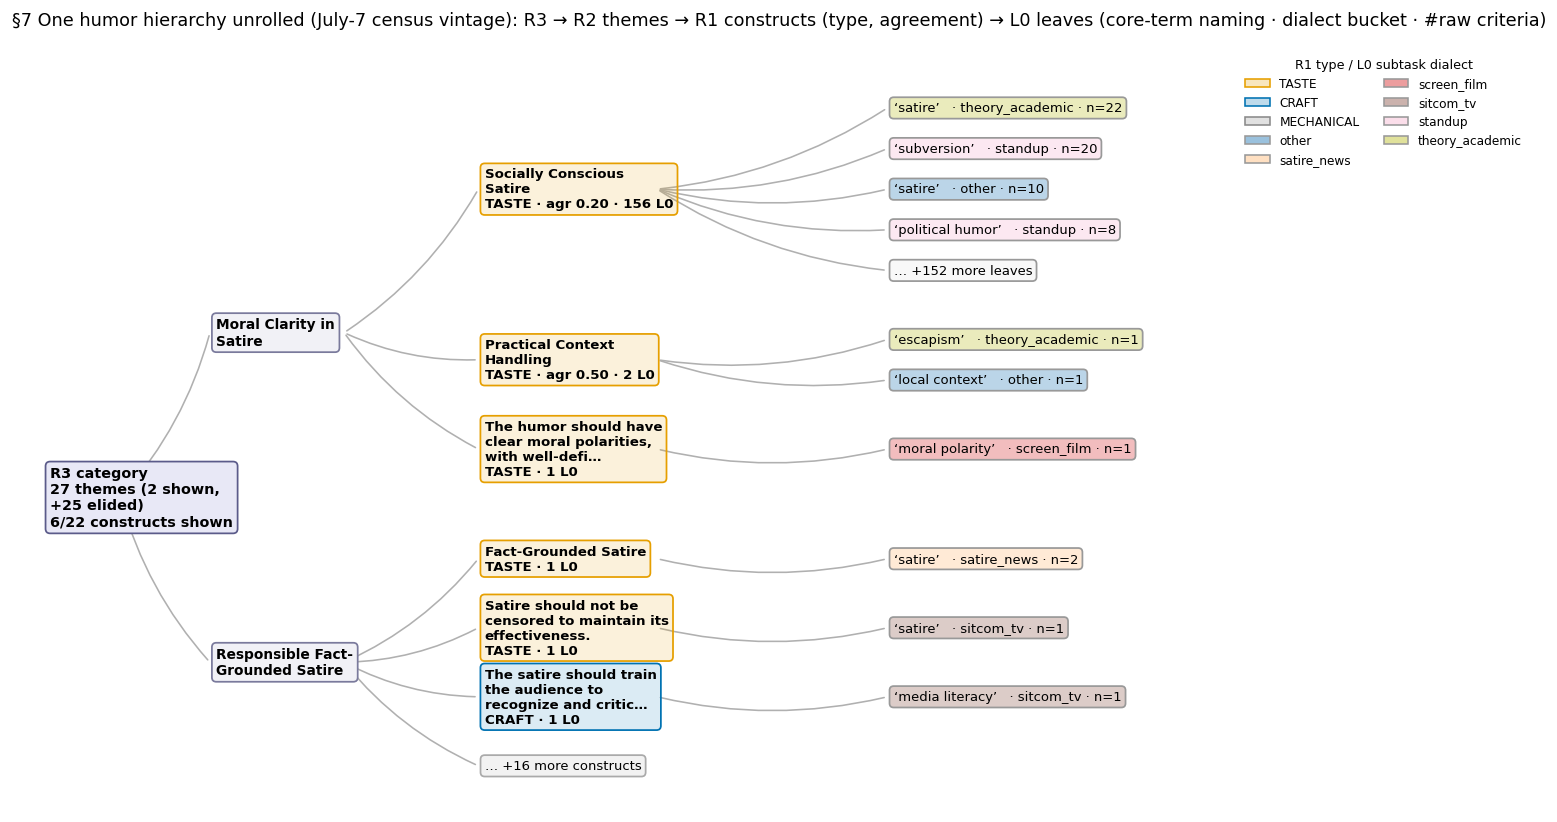

saved: /Users/spangher/Projects/stanford-research/norm-research/notebooks/figures/2026-07-08__codability_tree_humor.png


In [52]:
task = "humor"
# VINTAGE PIN (2026-07-16): this figure belongs to the July-7 codability-census hierarchy, the one
# prov/scored/btype are keyed to. partition_humor_R1.json is now the certified 2026-07-13 canonical
# (different group ids), so the census R1 (749 groups) is recovered from
# codability/partition_key2R1_humor.json (raw key -> R1) composed with L0v2 (raw key -> L0 leaf);
# every L0v2 leaf maps to exactly one census R1 group (verified unambiguous). R2/R3 are read from
# vintage-pinned copies so later canonical promotions cannot break this cell. The R3 file was
# coarsened to 6 large categories on 2026-07-11 04:16 (post-render, no backup), so we draw the best
# few themes of one category with an explicit elision marker instead of a whole category.
L0p = {k: str(v) for k, v in jload(f"{OUT}/partition_{task}_L0v2.json").items()}
_k2r1 = jload(f"{CD}/partition_key2R1_{task}.json")
_vote = defaultdict(Counter)
for _k, _g in jload(f"{OUT}/partition_{task}_L0v2.json").items():
    if _k in _k2r1:
        _vote[str(_g)][str(_k2r1[_k])] += 1
R1p = {l0: c.most_common(1)[0][0] for l0, c in _vote.items()}
R2p = {str(k): str(v) for k, v in jload(f"{OUT}/partition_{task}_R2_vintage_20260707.json").items()}
R3p = {str(k): str(v) for k, v in jload(f"{OUT}/partition_{task}_R3_vintage_20260711.json").items()}
n1 = {}
for r in prov[task]:
    n1.setdefault(r["construct"], r["construct_name"])
n2 = {g: (v or {}).get("name", g) for g, v in jload(f"{OUT}/node_names_{task}_R2.json").items()}
l0size = Counter(L0p.values())
pv = {r["l0"]: r for r in prov[task]}
agree = {r["construct"]: r.get("agreement") for r in scored[task]}
mem1, mem2, mem3 = defaultdict(list), defaultdict(list), defaultdict(list)
for l, g in R1p.items():
    mem1[g].append(l)
for r1, g in R2p.items():
    mem2[g].append(r1)
for r2, g in R3p.items():
    mem3[g].append(r2)

# Guard against vintage drift: keep only entries that compose across levels.
mem2 = {g: [r1 for r1 in v if r1 in mem1] for g, v in mem2.items()}
mem2 = {g: v for g, v in mem2.items() if v}
mem3 = {g: [r2 for r2 in v if r2 in mem2] for g, v in mem3.items()}
mem3 = {g: v for g, v in mem3.items() if v}
assert mem3, (f"{task}: R1/R2/R3 partitions on disk do not compose (stale vintage - "
              "R2/R3 reference group ids from an older R1).")

PREF = ["punchline", "offense", "self-deprecation", "tension", "satire", "wordplay", "timing"]


def theme_key(r2):
    r1s = mem2[r2]
    nl = sum(min(len(mem1[r1]), 6) + (1 if len(mem1[r1]) > 6 else 0) for r1 in r1s)
    named_frac = np.mean([1.0 if pv.get(l) else 0.0 for r1 in r1s for l in mem1[r1]]) if r1s else 0
    pref = any(any(p in n1.get(r1, "").lower() for p in PREF) for r1 in r1s)
    sized = 2 <= len(r1s) <= 4 and 4 <= nl <= 14
    return (sized, pref, named_frac, -abs(nl - 9))


best_theme = max(mem2, key=theme_key)
r3 = next(c for c, r2s in mem3.items() if best_theme in r2s)
show_r2 = sorted(mem3[r3], key=theme_key, reverse=True)[:2]
hidden_r2 = len(mem3[r3]) - len(show_r2)


def r1_key(r1):
    named_frac = np.mean([1.0 if pv.get(l) else 0.0 for l in mem1[r1]])
    pref = any(p in n1.get(r1, "").lower() for p in PREF)
    return (pref, named_frac, -abs(len(mem1[r1]) - 4))


# assemble rows top-down, recording each leaf's y as we go
rowsT = []          # (id, parent_r1, label, bucket)
ly_map, r1_y, r2_y = {}, {}, {}
r1_draw = defaultdict(list)   # r2 -> [(r1_or_pseudo, elision_label_or_None)]
buckets_here = set()
yy = 0.0
for r2 in show_r2:
    r1list = sorted(mem2[r2], key=r1_key, reverse=True)
    show_r1, hidden_r1 = r1list[:3], max(0, len(r1list) - 3)
    for r1 in show_r1:
        ls = sorted(mem1[r1], key=lambda l: -l0size[l])
        shown, extra = ls[:4], max(0, len(ls) - 4)
        ys = []
        for l in shown:
            p = pv.get(l)
            term = f"‘{p['term']}’" if p else "(unnamed)"
            bk = p["bucket"] if p else "?"
            buckets_here.add(bk)
            rowsT.append((l, r1, f"{term}   · {bk} · n={l0size[l]}", bk))
            ly_map[l] = yy; ys.append(yy); yy -= 1.0
        if extra:
            iid = f"{r1}+more"
            rowsT.append((iid, r1, f"… +{extra} more leaves", "?"))
            ly_map[iid] = yy; ys.append(yy); yy -= 1.0
        if ys:
            r1_y[r1] = float(np.mean(ys))
        r1_draw[r2].append((r1, None))
        yy -= 0.7
    if hidden_r1:
        iid = f"{r2}+cons"
        ly_map[iid] = yy; r1_y[iid] = yy; yy -= 1.0
        r1_draw[r2].append((iid, f"… +{hidden_r1} more constructs"))
        yy -= 0.7
    r2ys = [r1_y[r1] for r1, _ in r1_draw[r2]]
    if r2ys:
        r2_y[r2] = float(np.mean(r2ys))
    yy -= 1.0

bl = sorted(buckets_here)
bcmap = {b: mpl.colormaps["tab20"](i / max(1, len(bl))) for i, b in enumerate(bl)}
bcmap["?"] = (.92, .92, .92, 1)

Xr3, Xr2, Xr1, Xl0 = 0.00, 0.13, 0.34, 0.66
fig_h = max(4.5, 0.42 * len(ly_map) + 2.2)
fig, ax = plt.subplots(figsize=(13.4, fig_h))
ax.set_xlim(-0.02, 1.16)
ax.set_ylim(min(ly_map.values()) - 1.1, 1.5)
ax.axis("off")


def box(x, yv, text, fc, ec, fs=8.4, ha="left", bold=False):
    ax.text(x, yv, text, ha=ha, va="center", fontsize=fs,
            fontweight="bold" if bold else "normal",
            bbox=dict(boxstyle="round,pad=0.32", fc=fc, ec=ec, lw=1.1))


def edge(x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-", color="#b0b0b0", lw=1.0,
                                connectionstyle="arc3,rad=0.12"))


for iid, par, lab, bk in rowsT:
    yv = ly_map[iid]
    edge(Xr1 + 0.135, r1_y[par], Xl0 - 0.005, yv)
    box(Xl0, yv, lab, to_rgba(bcmap[bk], 0.30), "#999999", fs=8.2)
for r2 in show_r2:
    for r1, elab in r1_draw[r2]:
        if elab:
            edge(Xr2 + 0.10, r2_y[r2], Xr1 - 0.005, r1_y[r1])
            box(Xr1, r1_y[r1], elab, "#f2f2f2", "#aaaaaa", fs=8.2)
            continue
        tt = btype[task].get(r1)
        a = agree.get(r1)
        _nm = n1.get(r1, r1)
        lab = textwrap.fill(_nm[:60] + ("…" if len(_nm) > 60 else ""), 24)
        lab += f"\n{tt or '?'} · agr {a:.2f} · {len(mem1[r1])} L0" if a is not None else f"\n{tt or '?'} · {len(mem1[r1])} L0"
        col = TCOL.get(tt, "#8a8a8a")
        edge(Xr2 + 0.10, r2_y[r2], Xr1 - 0.005, r1_y[r1])
        box(Xr1, r1_y[r1], lab, to_rgba(col, 0.14), col, fs=8.4, bold=True)
    box(Xr2, r2_y[r2], textwrap.fill(n2.get(r2, r2), 18), "#f1f1f6", "#7a7a9c", fs=8.6, bold=True)
r3y = float(np.mean(list(r2_y.values())))
for r2 in show_r2:
    edge(Xr3 + 0.055, r3y, Xr2 - 0.005, r2_y[r2])
nr1 = sum(len(mem2[r2]) for r2 in show_r2)
nr1_shown = sum(1 for r2 in show_r2 for _, e in r1_draw[r2] if e is None)
box(Xr3, r3y, f"R3 category\n{len(mem3[r3])} themes ({len(show_r2)} shown,\n+{hidden_r2} elided)\n{nr1_shown}/{nr1} constructs shown",
    "#e8e8f6", "#5b5b8a", fs=9, bold=True)

handles = [mpl.patches.Patch(fc=to_rgba(TCOL[t_], .25), ec=TCOL[t_], label=t_) for t_ in ["TASTE", "CRAFT", "MECHANICAL"]]
handles += [mpl.patches.Patch(fc=to_rgba(bcmap[b], .45), ec="#999", label=b) for b in bl if b != "?"]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=7.6, ncol=2,
          title="R1 type / L0 subtask dialect", title_fontsize=8)
ax.set_title("§7 One humor hierarchy unrolled (July-7 census vintage): R3 → R2 themes → R1 constructs "
             "(type, agreement) → L0 leaves (core-term naming · dialect bucket · #raw criteria)",
             fontsize=11, pad=14)
plt.tight_layout()
fig.savefig(f"{ROOT}/notebooks/figures/2026-07-08__codability_tree_{task}.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", f"{ROOT}/notebooks/figures/2026-07-08__codability_tree_{task}.png")


## §8 — Verdict summary, and what's parked

**Summary of findings** (each backed by a section above):

1. **"TASTE is more codable than CRAFT" is NULL.** The raw gap (§1) is a size/selection artifact. Rarefaction + label permutation kill it in both tasks (p = .17–.97). Humor's residual gap rides on one construct, *Verbal Wit* (dropping it cuts the gap 71%; dropping top-3 cuts it 94%). Two independent advisor models concurred: don't publish the type contrast. *(§1–§3)*

2. **Naming agreement collapses mechanically with construct size** (Spearman ρ = −0.85 humor, −0.82 creative writing), holds within type, and is **low in absolute terms everywhere** (rarefied agreement ~0.13–0.24 regardless of type). *(§2)*

3. **Evaluative vocabularies are subtask-DIALECTAL.** Within-subtask namings agree far more than cross-subtask, on **both instruments** (GLM core terms *and* author's own verbatim key terms). Humor shows ~25× stronger agreement within-subtask (p = .0000); creative writing ~6× (p = .0040). The core-term instrument initially missed creative writing's effect due to low power, but the author-vocabulary instrument revealed it. *(§4)*

4. **Most sources never name the concept at all** — they describe it. Author-lexicon unnamed rate: **0.69 (humor), 0.62 (creative writing)**. When they do name, creative writing names more often but agrees less (0.23 vs 0.35 agreement; 3.6 vs 2.5 bits entropy). *(§6)*

5. **The GLM core-term layer is faithful per item** (86–92% fidelity, 8/8 blinded anchors PASS) but speaks **GLM's lexicon, not the community's** (matches author's own head term only 13.8% / 11.9%). The verbatim author-lexicon census is the faithful Brown & Lenneberg instrument. *(§5)*

**Open / parked.** One-more-task deep dive (journalism recommended: ~3k criteria, contexts ready, ≈$0 marginal on Max-plan subagents, ~1.5 hours; math needs a dataset-path shim) — parked pending weekly quota reset. Coherence-vs-size remains unseparable in this design (report as limitation). All numbers reproducible via `outputs/lexicon/codability_audit/`.